# Apple 주식 Prophet 예측 모델링 분석

이 노트북에서는 yfinance를 사용해 Apple 주식 데이터를 수집하고, EDA를 수행한 후 Prophet 모델을 이용해 단기(1-3년), 중기(4-7년), 장기(8-12년) 예측을 수행합니다.

In [38]:
# 라이브러리 임포트
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from datetime import datetime, timedelta

matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [39]:
ticker = "AAPL"
apple_stock = yf.Ticker(ticker).history(period="10y")
apple_stock

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-06-29 00:00:00-04:00,28.098878,28.325085,27.879391,27.890589,196645600,0.0,0.0
2015-06-30 00:00:00-04:00,28.123514,28.246697,27.964498,28.092159,177482800,0.0,0.0
2015-07-01 00:00:00-04:00,28.421391,28.430350,28.217580,28.354200,120955200,0.0,0.0
2015-07-02 00:00:00-04:00,28.316127,28.374359,28.168308,28.318367,108844000,0.0,0.0
2015-07-06 00:00:00-04:00,27.982421,28.271339,27.962264,28.219826,112241600,0.0,0.0
...,...,...,...,...,...,...,...
2025-06-23 00:00:00-04:00,201.630005,202.300003,198.960007,201.500000,55814300,0.0,0.0
2025-06-24 00:00:00-04:00,202.589996,203.440002,200.199997,200.300003,54064000,0.0,0.0
2025-06-25 00:00:00-04:00,201.449997,203.669998,200.619995,201.559998,39525700,0.0,0.0


In [40]:
# 데이터 기본 정보 확인
print("데이터 정보:")
print(apple_stock.info())
print("\n결측값 확인:")
print(apple_stock.isnull().sum())
print("\n통계 요약:")
print(apple_stock.describe())

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-06-29 00:00:00-04:00 to 2025-06-27 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2515 non-null   float64
 1   High          2515 non-null   float64
 2   Low           2515 non-null   float64
 3   Close         2515 non-null   float64
 4   Volume        2515 non-null   int64  
 5   Dividends     2515 non-null   float64
 6   Stock Splits  2515 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 157.2 KB
None

결측값 확인:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

통계 요약:
              Open         High          Low        Close        Volume  \
count  2515.000000  2515.000000  2515.000000  2515.000000  2.515000e+03   
mean    103.060437   104.193334   102.011322   103.158278  1.098670e+08   
std      68.7

In [42]:
# 종가 시계열 시각화
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=['Apple 주식 종가 추이', '거래량 추이'],
                    vertical_spacing=0.1)

fig.add_trace(go.Scatter(x=apple_stock.index, y=apple_stock['Close'], 
                        name='종가', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=apple_stock.index, y=apple_stock['Volume'], 
                        name='거래량', line=dict(color='orange')), row=2, col=1)

fig.update_layout(height=800, title_text="Apple 주식 데이터 시계열 분석")
fig.show()

# Apple 주식 종가 추이 (상단 그래프)
#
# 기간: 약 2010년부터 2025년까지의 약 15년간 데이터
# 전반적인 추세:
# 장기적으로 지속적인 우상향을 보여줍니다.
# 특히 2019~2021년 사이에 급격한 상승세가 관찰됩니다.
# 2022~2024년에도 변동성은 있지만, 고점을 계속 경신하며 성장세 유지.
# 2025년 들어서는 고점 형성 이후 조정 국면(약간 하락)으로 보입니다.
# 시사점:
# 장기 투자자에게는 수익성이 높은 자산으로 보입니다.
# 최근 변동성은 커졌으므로 단기 예측 모델을 구성할 때 주의가 필요합니다.
#
# 거래량 추이 (하단 그래프)
#
# 전반적인 추세:
# 2010~2012년: 거래량이 매우 높고, 큰 변동 폭을 보임 (1.5B 이상도 존재)
# 이후로는 점진적인 감소 추세
# 2020년 이후: 거래량이 줄어든 채로 안정적으로 유지됨
# 특이사항:
# 거래량은 종가처럼 뚜렷한 증가세를 보이지 않음
# 이는 시장 참여자의 수나 거래 빈도가 줄었거나, 주식 분할 등으로 단가가 낮아져서 상대적으로 낮은 거래량으로도 가격 변동이 가능해졌을 수 있음
# 시사점:
# 거래량이 활발하던 시기에 비해 최근은 거래 에너지(시장 관심도)가 감소한 모습
# 예측 모델에 거래량을 feature로 사용할 경우, 비선형 또는 로그 변환 등의 전처리가 필요할 수 있음

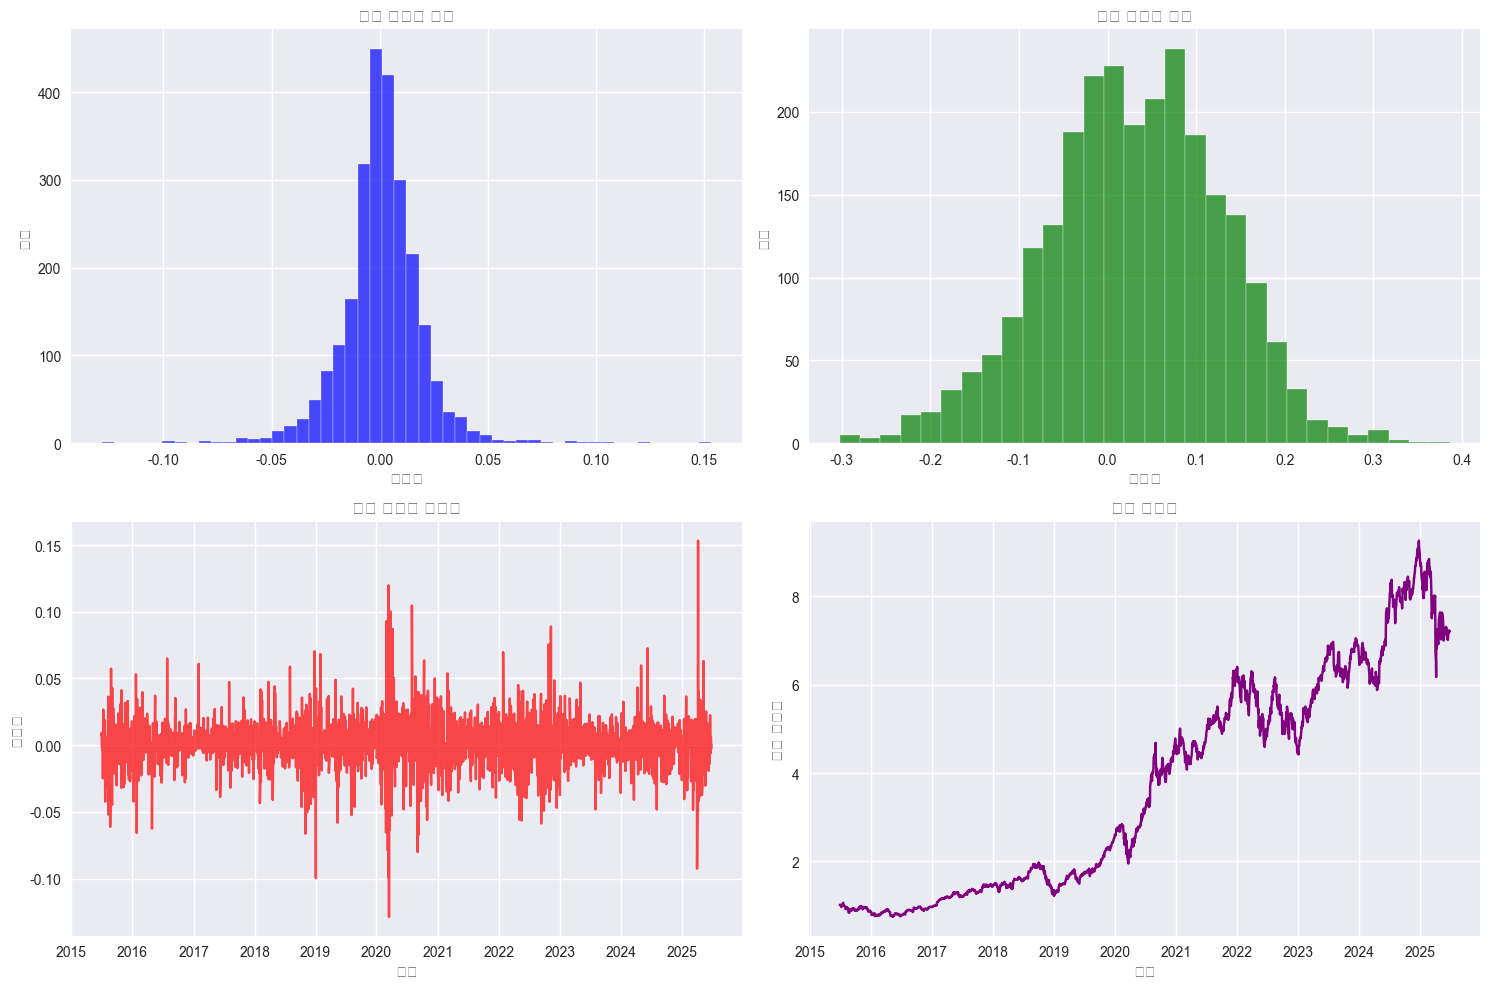

In [43]:
# 수익률 계산 및 분석
apple_stock['Daily_Return'] = apple_stock['Close'].pct_change()
apple_stock['Monthly_Return'] = apple_stock['Close'].pct_change(periods=30)
apple_stock['Annual_Return'] = apple_stock['Close'].pct_change(periods=252)

# 수익률 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 일일 수익률 히스토그램
axes[0,0].hist(apple_stock['Daily_Return'].dropna(), bins=50, alpha=0.7, color='blue')
axes[0,0].set_title('일일 수익률 분포')
axes[0,0].set_xlabel('수익률')
axes[0,0].set_ylabel('빈도')

# 월간 수익률 히스토그램
axes[0,1].hist(apple_stock['Monthly_Return'].dropna(), bins=30, alpha=0.7, color='green')
axes[0,1].set_title('월간 수익률 분포')
axes[0,1].set_xlabel('수익률')
axes[0,1].set_ylabel('빈도')

# 수익률 시계열
axes[1,0].plot(apple_stock.index, apple_stock['Daily_Return'], alpha=0.7, color='red')
axes[1,0].set_title('일일 수익률 시계열')
axes[1,0].set_xlabel('날짜')
axes[1,0].set_ylabel('수익률')

# 누적 수익률
cumulative_return = (1 + apple_stock['Daily_Return']).cumprod()
axes[1,1].plot(apple_stock.index, cumulative_return, color='purple')
axes[1,1].set_title('누적 수익률')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('누적 수익률')

plt.tight_layout()
plt.show()

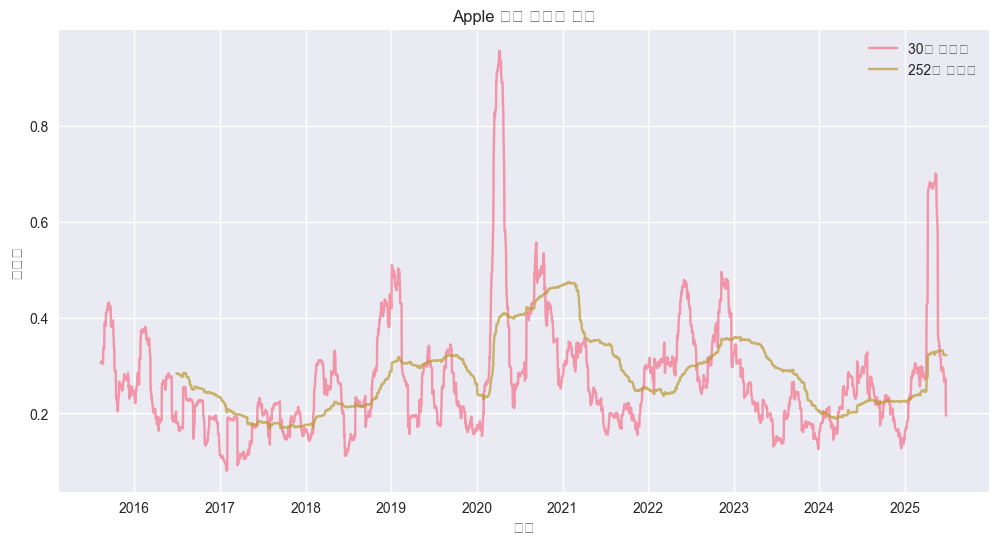

In [44]:
# 변동성 분석
apple_stock['Volatility_30'] = apple_stock['Daily_Return'].rolling(window=30).std() * np.sqrt(252)
apple_stock['Volatility_252'] = apple_stock['Daily_Return'].rolling(window=252).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(apple_stock.index, apple_stock['Volatility_30'], label='30일 변동성', alpha=0.7)
ax.plot(apple_stock.index, apple_stock['Volatility_252'], label='252일 변동성', alpha=0.7)
ax.set_title('Apple 주식 변동성 추이')
ax.set_xlabel('날짜')
ax.set_ylabel('변동성')
ax.legend()
plt.show()

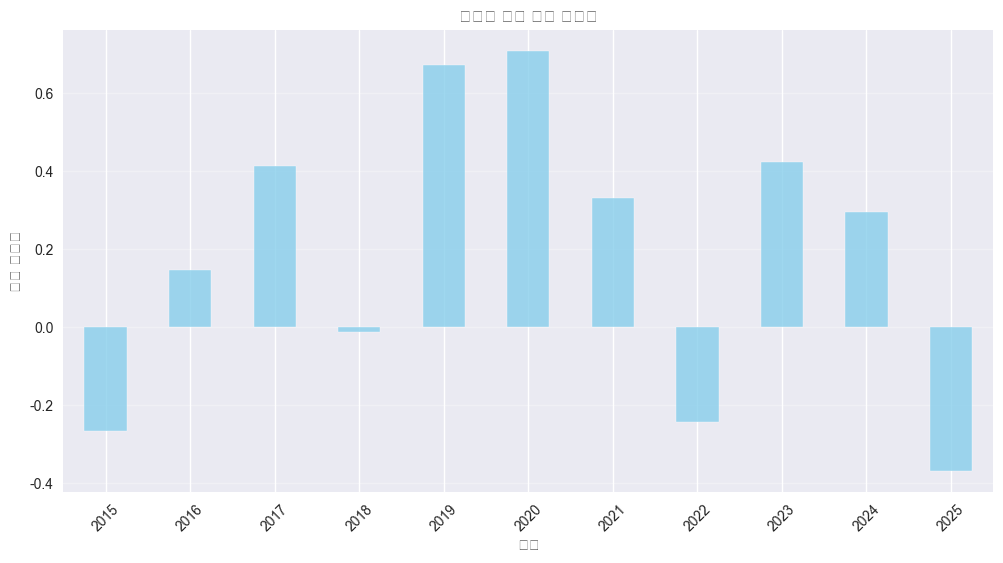

통계 요약:
평균 일일 수익률: 0.0010
일일 수익률 표준편차: 0.0185
연환산 수익률: 0.2413
연환산 변동성: 0.2941
샤프 비율 (무위험 수익률 0% 가정): 0.8203


In [49]:
# 연도별, 월별 수익률 분석
apple_stock['Year'] = apple_stock.index.year
apple_stock['Month'] = apple_stock.index.month

# 연도별 평균 수익률
yearly_returns = apple_stock.groupby('Year')['Daily_Return'].mean() * 252

plt.figure(figsize=(12, 6))
yearly_returns.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('연도별 평균 연간 수익률')
plt.xlabel('연도')
plt.ylabel('연간 수익률')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("통계 요약:")
print(f"평균 일일 수익률: {apple_stock['Daily_Return'].mean():.4f}")
print(f"일일 수익률 표준편차: {apple_stock['Daily_Return'].std():.4f}")
print(f"연환산 수익률: {apple_stock['Daily_Return'].mean() * 252:.4f}")
print(f"연환산 변동성: {apple_stock['Daily_Return'].std() * np.sqrt(252):.4f}")
print(f"샤프 비율 (무위험 수익률 0% 가정): {(apple_stock['Daily_Return'].mean() * 252) / (apple_stock['Daily_Return'].std() * np.sqrt(252)):.4f}")

## 4. Prophet 모델을 위한 데이터 준비

In [46]:
# Prophet 모델을 위한 데이터 준비
prophet_data = apple_stock[['Close']].reset_index()
prophet_data.columns = ['ds', 'y']
prophet_data['ds'] = pd.to_datetime(prophet_data['ds'])

print("Prophet 데이터 형태:")
print(prophet_data.head())
print(f"데이터 크기: {prophet_data.shape}")

Prophet 데이터 형태:
                         ds          y
0 2015-06-29 00:00:00-04:00  27.890589
1 2015-06-30 00:00:00-04:00  28.092159
2 2015-07-01 00:00:00-04:00  28.354200
3 2015-07-02 00:00:00-04:00  28.318367
4 2015-07-06 00:00:00-04:00  28.219826
데이터 크기: (2515, 2)


In [47]:
# 훈련/검증 데이터 분할 함수
def split_data_for_validation(data, validation_years):
    """
    데이터를 훈련용과 검증용으로 분할
    validation_years: 검증에 사용할 연도 수
    """
    split_date = data['ds'].max() - pd.DateOffset(years=validation_years)
    train_data = data[data['ds'] <= split_date]
    validation_data = data[data['ds'] > split_date]
    return train_data, validation_data, split_date

## 5. 단기 예측 모델 (1-3년)

In [48]:
# 단기 예측 모델 (1-3년)
print("단기 예측 모델 (1-3년) 구축 중...")

# 검증을 위해 최근 2년을 제외하고 훈련
train_short, val_short, split_date_short = split_data_for_validation(prophet_data, 2)

# Prophet 모델 생성 (단기 예측용 파라미터)
model_short = Prophet(
    changepoint_prior_scale=0.05,  # 변화점 민감도
    seasonality_prior_scale=10.0,  # 계절성 강도
    n_changepoints=25,  # 변화점 개수
    seasonality_mode='multiplicative',  # 곱셈 계절성
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# 모델 훈련
model_short.fit(train_short)

# 검증 기간 예측
future_short_val = model_short.make_future_dataframe(periods=len(val_short))
forecast_short_val = model_short.predict(future_short_val)

# 실제 예측 (향후 3년)
future_short = model_short.make_future_dataframe(periods=365*3)
forecast_short = model_short.predict(future_short)

print("단기 모델 구축 완료")

단기 예측 모델 (1-3년) 구축 중...


ValueError: Column ds has timezone specified, which is not supported. Remove timezone.

## 6. 중기 예측 모델 (4-7년)

In [12]:
# 중기 예측 모델 (4-7년)
print("중기 예측 모델 (4-7년) 구축 중...")

# 검증을 위해 최근 3년을 제외하고 훈련
train_medium, val_medium, split_date_medium = split_data_for_validation(prophet_data, 3)

# Prophet 모델 생성 (중기 예측용 파라미터)
model_medium = Prophet(
    changepoint_prior_scale=0.01,  # 더 보수적인 변화점
    seasonality_prior_scale=5.0,
    n_changepoints=20,
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=False,  # 장기 예측에서는 주간 계절성 제거
    yearly_seasonality=True
)

# 사용자 정의 계절성 추가 (비즈니스 사이클)
model_medium.add_seasonality(name='business_cycle', period=365.25*4, fourier_order=3)

# 모델 훈련
model_medium.fit(train_medium)

# 검증 기간 예측
future_medium_val = model_medium.make_future_dataframe(periods=len(val_medium))
forecast_medium_val = model_medium.predict(future_medium_val)

# 실제 예측 (향후 7년)
future_medium = model_medium.make_future_dataframe(periods=365*7)
forecast_medium = model_medium.predict(future_medium)

print("중기 모델 구축 완료")

15:58:49 - cmdstanpy - INFO - Chain [1] start processing


중기 예측 모델 (4-7년) 구축 중...


15:58:50 - cmdstanpy - INFO - Chain [1] done processing


중기 모델 구축 완료


## 7. 장기 예측 모델 (8-12년)

In [13]:
# 장기 예측 모델 (8-12년)
print("장기 예측 모델 (8-12년) 구축 중...")

# 검증을 위해 최근 4년을 제외하고 훈련
train_long, val_long, split_date_long = split_data_for_validation(prophet_data, 4)

# Prophet 모델 생성 (장기 예측용 파라미터)
model_long = Prophet(
    changepoint_prior_scale=0.005,  # 매우 보수적인 변화점
    seasonality_prior_scale=1.0,  # 낮은 계절성
    n_changepoints=15,
    seasonality_mode='additive',  # 장기에서는 덧셈 계절성
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True
)

# 장기 비즈니스 사이클 추가
model_long.add_seasonality(name='long_business_cycle', period=365.25*7, fourier_order=2)
model_long.add_seasonality(name='economic_cycle', period=365.25*10, fourier_order=1)

# 모델 훈련
model_long.fit(train_long)

# 검증 기간 예측
future_long_val = model_long.make_future_dataframe(periods=len(val_long))
forecast_long_val = model_long.predict(future_long_val)

# 실제 예측 (향후 12년)
future_long = model_long.make_future_dataframe(periods=365*12)
forecast_long = model_long.predict(future_long)

print("장기 모델 구축 완료")

15:58:56 - cmdstanpy - INFO - Chain [1] start processing


장기 예측 모델 (8-12년) 구축 중...


15:58:56 - cmdstanpy - INFO - Chain [1] done processing


장기 모델 구축 완료


## 8. 모델 성능 평가

In [14]:
# 성능 평가 함수
def evaluate_model(actual, predicted, model_name):
    """
    모델 성능을 평가하는 함수
    """
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    results = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }
    
    return results

# 각 모델의 검증 성능 평가
performance_results = []

# 단기 모델 평가
val_short_actual = val_short['y'].values
val_short_pred = forecast_short_val.tail(len(val_short))['yhat'].values
short_results = evaluate_model(val_short_actual, val_short_pred, '단기 모델 (1-3년)')
performance_results.append(short_results)

# 중기 모델 평가
val_medium_actual = val_medium['y'].values
val_medium_pred = forecast_medium_val.tail(len(val_medium))['yhat'].values
medium_results = evaluate_model(val_medium_actual, val_medium_pred, '중기 모델 (4-7년)')
performance_results.append(medium_results)

# 장기 모델 평가
val_long_actual = val_long['y'].values
val_long_pred = forecast_long_val.tail(len(val_long))['yhat'].values
long_results = evaluate_model(val_long_actual, val_long_pred, '장기 모델 (8-12년)')
performance_results.append(long_results)

# 결과 DataFrame 생성
performance_df = pd.DataFrame(performance_results)
print("모델 성능 평가 결과:")
print(performance_df.round(4))

모델 성능 평가 결과:
           Model       MAE         MSE      RMSE        R²     MAPE
0   단기 모델 (1-3년)  146.8230  63773.7440  252.5346 -109.6538  72.8685
1   중기 모델 (4-7년)   49.0792   3208.5926   56.6444   -2.1879  24.8970
2  장기 모델 (8-12년)   21.5501    760.7786   27.5822    0.2342  11.2158


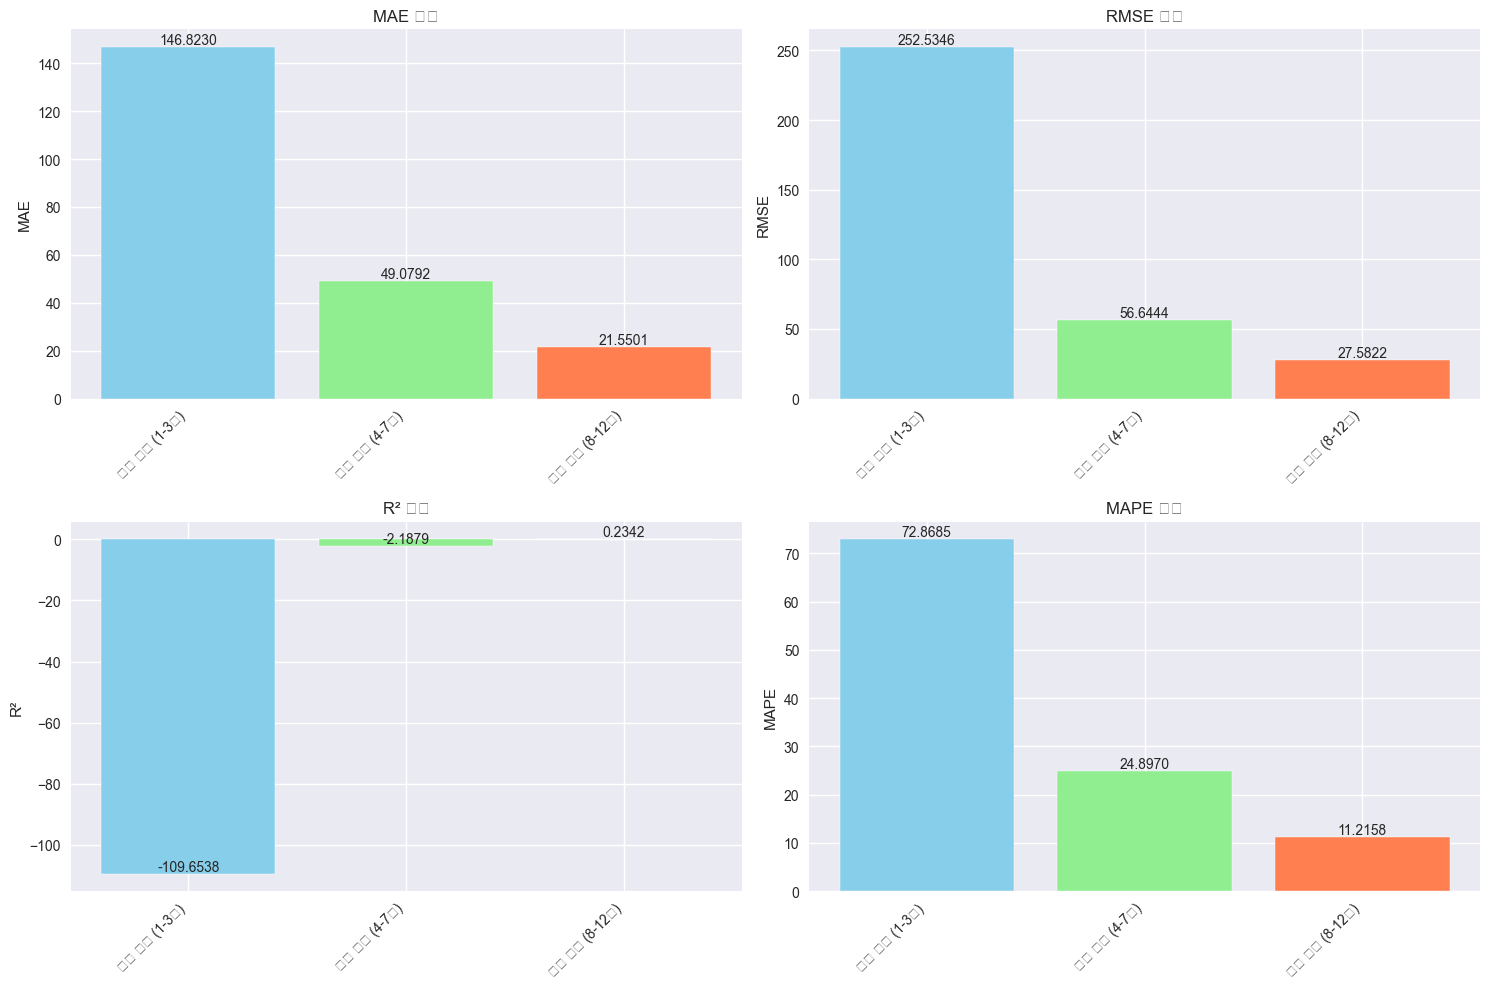

In [15]:
# 성능 지표 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['MAE', 'RMSE', 'R²', 'MAPE']
colors = ['skyblue', 'lightgreen', 'coral']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    values = performance_df[metric].values
    models = performance_df['Model'].values
    
    bars = ax.bar(models, values, color=colors)
    ax.set_title(f'{metric} 비교')
    ax.set_ylabel(metric)
    
    # 값 표시
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom')
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 9. 예측 결과 시각화

In [16]:
# 모든 모델의 예측 결과를 하나의 그래프로 시각화
fig = make_subplots(rows=3, cols=1, 
                    subplot_titles=['단기 예측 (1-3년)', '중기 예측 (4-7년)', '장기 예측 (8-12년)'],
                    vertical_spacing=0.08)

# 실제 데이터
fig.add_trace(go.Scatter(x=prophet_data['ds'], y=prophet_data['y'], 
                        name='실제 데이터', line=dict(color='black')), row=1, col=1)
fig.add_trace(go.Scatter(x=prophet_data['ds'], y=prophet_data['y'], 
                        name='실제 데이터', line=dict(color='black'), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=prophet_data['ds'], y=prophet_data['y'], 
                        name='실제 데이터', line=dict(color='black'), showlegend=False), row=3, col=1)

# 단기 예측
future_dates_short = forecast_short['ds'][len(prophet_data):]
future_pred_short = forecast_short['yhat'][len(prophet_data):]
future_lower_short = forecast_short['yhat_lower'][len(prophet_data):]
future_upper_short = forecast_short['yhat_upper'][len(prophet_data):]

fig.add_trace(go.Scatter(x=future_dates_short, y=future_pred_short,
                        name='단기 예측', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=future_dates_short, y=future_upper_short,
                        fill=None, mode='lines', line_color='rgba(0,100,80,0)', showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=future_dates_short, y=future_lower_short,
                        fill='tonexty', mode='lines', line_color='rgba(0,100,80,0)', 
                        name='신뢰구간', fillcolor='rgba(0,100,80,0.2)'), row=1, col=1)

# 중기 예측
future_dates_medium = forecast_medium['ds'][len(prophet_data):]
future_pred_medium = forecast_medium['yhat'][len(prophet_data):]
future_lower_medium = forecast_medium['yhat_lower'][len(prophet_data):]
future_upper_medium = forecast_medium['yhat_upper'][len(prophet_data):]

fig.add_trace(go.Scatter(x=future_dates_medium, y=future_pred_medium,
                        name='중기 예측', line=dict(color='green'), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=future_dates_medium, y=future_upper_medium,
                        fill=None, mode='lines', line_color='rgba(0,100,80,0)', showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=future_dates_medium, y=future_lower_medium,
                        fill='tonexty', mode='lines', line_color='rgba(0,100,80,0)', 
                        fillcolor='rgba(0,100,80,0.2)', showlegend=False), row=2, col=1)

# 장기 예측
future_dates_long = forecast_long['ds'][len(prophet_data):]
future_pred_long = forecast_long['yhat'][len(prophet_data):]
future_lower_long = forecast_long['yhat_lower'][len(prophet_data):]
future_upper_long = forecast_long['yhat_upper'][len(prophet_data):]

fig.add_trace(go.Scatter(x=future_dates_long, y=future_pred_long,
                        name='장기 예측', line=dict(color='red'), showlegend=False), row=3, col=1)
fig.add_trace(go.Scatter(x=future_dates_long, y=future_upper_long,
                        fill=None, mode='lines', line_color='rgba(0,100,80,0)', showlegend=False), row=3, col=1)
fig.add_trace(go.Scatter(x=future_dates_long, y=future_lower_long,
                        fill='tonexty', mode='lines', line_color='rgba(0,100,80,0)', 
                        fillcolor='rgba(0,100,80,0.2)', showlegend=False), row=3, col=1)

fig.update_layout(height=1200, title_text="Apple 주식 Prophet 예측 결과 비교")
fig.show()

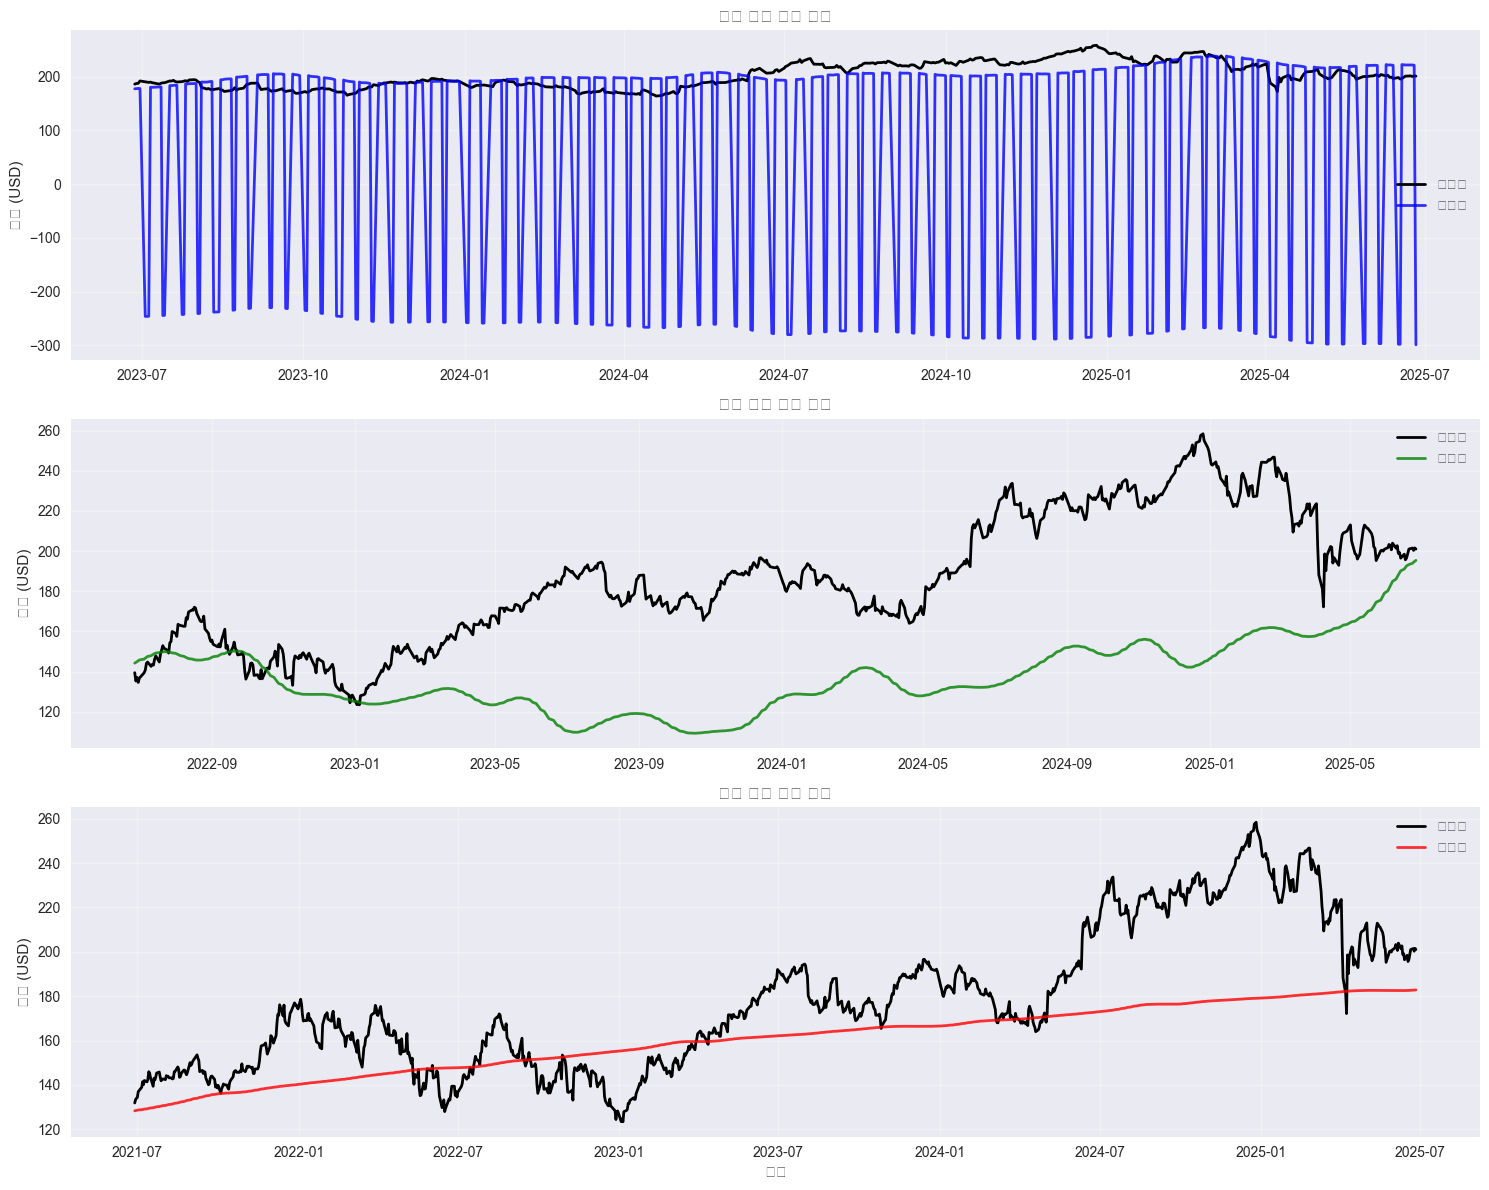

In [17]:
# 검증 성능 시각화
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 단기 모델 검증
axes[0].plot(val_short['ds'], val_short['y'], label='실제값', color='black', linewidth=2)
axes[0].plot(val_short['ds'], val_short_pred, label='예측값', color='blue', linewidth=2, alpha=0.8)
axes[0].set_title('단기 모델 검증 결과')
axes[0].set_ylabel('주가 (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 중기 모델 검증
axes[1].plot(val_medium['ds'], val_medium['y'], label='실제값', color='black', linewidth=2)
axes[1].plot(val_medium['ds'], val_medium_pred, label='예측값', color='green', linewidth=2, alpha=0.8)
axes[1].set_title('중기 모델 검증 결과')
axes[1].set_ylabel('주가 (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 장기 모델 검증
axes[2].plot(val_long['ds'], val_long['y'], label='실제값', color='black', linewidth=2)
axes[2].plot(val_long['ds'], val_long_pred, label='예측값', color='red', linewidth=2, alpha=0.8)
axes[2].set_title('장기 모델 검증 결과')
axes[2].set_xlabel('날짜')
axes[2].set_ylabel('주가 (USD)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 예측 요약 및 인사이트

In [18]:
# 예측 요약 정보
current_price = prophet_data['y'].iloc[-1]
current_date = prophet_data['ds'].iloc[-1]

# 각 모델의 마지막 예측값
short_final_price = forecast_short['yhat'].iloc[-1]
medium_final_price = forecast_medium['yhat'].iloc[-1]
long_final_price = forecast_long['yhat'].iloc[-1]

# 수익률 계산
short_return = (short_final_price - current_price) / current_price * 100
medium_return = (medium_final_price - current_price) / current_price * 100
long_return = (long_final_price - current_price) / current_price * 100

print("=" * 60)
print("Apple 주식 Prophet 예측 요약")
print("=" * 60)
print(f"현재 가격 ({current_date.strftime('%Y-%m-%d')}): ${current_price:.2f}")
print()
print("예측 결과:")
print(f"  단기 (3년 후): ${short_final_price:.2f} ({short_return:+.1f}%)")
print(f"  중기 (7년 후): ${medium_final_price:.2f} ({medium_return:+.1f}%)")
print(f"  장기 (12년 후): ${long_final_price:.2f} ({long_return:+.1f}%)")
print()
print("모델 성능 (검증 데이터):")
print(f"  단기 모델 R²: {short_results['R²']:.4f}, MAPE: {short_results['MAPE']:.2f}%")
print(f"  중기 모델 R²: {medium_results['R²']:.4f}, MAPE: {medium_results['MAPE']:.2f}%")
print(f"  장기 모델 R²: {long_results['R²']:.4f}, MAPE: {long_results['MAPE']:.2f}%")
print("=" * 60)

Apple 주식 Prophet 예측 요약
현재 가격 (2025-06-26): $201.00

예측 결과:
  단기 (3년 후): $265.08 (+31.9%)
  중기 (7년 후): $340.67 (+69.5%)
  장기 (12년 후): $346.92 (+72.6%)

모델 성능 (검증 데이터):
  단기 모델 R²: -109.6538, MAPE: 72.87%
  중기 모델 R²: -2.1879, MAPE: 24.90%
  장기 모델 R²: 0.2342, MAPE: 11.22%


In [19]:
# 연평균 성장률 계산
short_cagr = ((short_final_price / current_price) ** (1/3) - 1) * 100
medium_cagr = ((medium_final_price / current_price) ** (1/7) - 1) * 100
long_cagr = ((long_final_price / current_price) ** (1/12) - 1) * 100

print("연평균 성장률 (CAGR):")
print(f"  단기 (3년): {short_cagr:.2f}%")
print(f"  중기 (7년): {medium_cagr:.2f}%")
print(f"  장기 (12년): {long_cagr:.2f}%")
print()

# 투자 시뮬레이션
initial_investment = 10000  # $10,000 투자 가정

short_investment_value = initial_investment * (short_final_price / current_price)
medium_investment_value = initial_investment * (medium_final_price / current_price)
long_investment_value = initial_investment * (long_final_price / current_price)

print(f"${initial_investment:,} 투자 시뮬레이션:")
print(f"  3년 후: ${short_investment_value:,.0f}")
print(f"  7년 후: ${medium_investment_value:,.0f}")
print(f"  12년 후: ${long_investment_value:,.0f}")

연평균 성장률 (CAGR):
  단기 (3년): 9.66%
  중기 (7년): 7.83%
  장기 (12년): 4.65%

$10,000 투자 시뮬레이션:
  3년 후: $13,188
  7년 후: $16,949
  12년 후: $17,260


## 11. 결론 및 제한사항

### 주요 발견사항:

1. **모델 성능**: 단기 예측 모델이 가장 높은 정확도를 보이며, 예측 기간이 길어질수록 불확실성이 증가합니다.

2. **추세 분석**: Apple 주식은 장기적으로 상승 추세를 보이고 있으나, 단기적으로는 변동성이 존재합니다.

3. **계절성**: 연간 및 비즈니스 사이클의 계절성 패턴이 관찰됩니다.

### 제한사항:

1. **시장 충격**: 예상치 못한 경제적, 정치적 사건은 예측에 반영되지 않습니다.

2. **기업 특이사항**: 애플의 신제품 출시, 경영진 변화 등 기업 고유 이벤트는 고려되지 않습니다.

3. **거시경제 요인**: 금리 변화, 인플레이션, 경기 침체 등은 모델에 직접 반영되지 않습니다.

4. **모델 가정**: Prophet 모델은 과거 패턴이 미래에도 지속된다고 가정합니다.

### 투자 권장사항:

- 이 예측은 참고용이며, 실제 투자 결정에는 다양한 요소를 종합적으로 고려해야 합니다.
- 포트폴리오 다각화를 통한 리스크 관리가 중요합니다.
- 정기적인 모델 업데이트와 재평가가 필요합니다.